# Example: Compare Ground Measurements with CAMS CRS Satellite Data
### 示例：对比地面观测与 CAMS CRS 卫星数据

This notebook demonstrates reading BSRN station data, adding REST2 clear-sky references (from MERRA-2 HF), running the QC suite, adding CRS satellite data (from HF), calculating solar geometry, and performing time averaging.

本手册演示读取 BSRN 站点数据、添加 REST2 晴空参考（来自 MERRA-2 HF）、运行 QC、添加 CRS 卫星数据（来自 HF）、计算太阳几何以及执行时间平均。

In [1]:
import os
import pandas as pd
import bsrn
import bsrn.visualization.calendar

# For inline plotting in some environments
%matplotlib inline

## 1. Parameters / 参数设置

In [2]:
station_code = "QIQ"
INPUT_FILE = "/Volumes/Macintosh Research/Data/bsrn-qc/data/QIQ/qiq0824.dat.gz"

print(f"--- Processing {station_code} for Aug 2024 ---")

--- Processing QIQ for Aug 2024 ---


## 2. Load Data, Solar Geometry and Clear-sky / 加载数据、计算几何与添加晴空模型


In [3]:
if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"File not found: {INPUT_FILE}")

df = bsrn.io.readers.read_station_to_archive(INPUT_FILE, logical_records="lr0100")
print(f"Loaded {len(df)} rows from archive.")

print("Calculating solar geometry...")
df = bsrn.physics.geometry.add_solpos_columns(df, station_code=station_code)

print("Fetching MERRA-2 and adding REST2 clear-sky columns...")
df = bsrn.modeling.clear_sky.add_clearsky_columns(df, station_code=station_code, model="rest2")

Loaded 44640 rows from archive.
Calculating solar geometry...
Fetching MERRA-2 and adding REST2 clear-sky columns...
Fetching MERRA-2 from Hugging Face: qiq/qiq0824_merra2.parquet


## 3. QC and Pre-processing / 质量控制与预处理 (去除异常值)


In [4]:
print("Running QC suite...")
df = bsrn.qc.wrapper.run_qc(df, station_code=station_code)

print("Removing data that failed any QC test...")
flag_cols = [c for c in df.columns if c.startswith("flag")]
df = df[df[flag_cols].sum(axis=1) == 0].copy()
df.drop(columns=flag_cols, inplace=True)
print(f"Rows remaining after QC filtering: {len(df)}")


Running QC suite...
Removing data that failed any QC test...
Rows remaining after QC filtering: 32510


## 4. Time Averaging and CRS Satellite Data / 时间平均与 CRS 卫星数据

In [5]:
print("Performing 1-hour time averaging...")
df_avg = bsrn.utils.pretty_average(df, rule="1h", alignment="ceiling")

print("Fetching and adding CRS all-sky columns...")
df_avg = bsrn.io.crs.add_crs_columns(df_avg, station_code=station_code)

df_avg.head()

Performing 1-hour time averaging...
Fetching and adding CRS all-sky columns...
Fetching CRS from Hugging Face: qiq/qiq0824_crs.parquet


,ghi,bni,dhi,lwd,temp,rh,pressure,zenith,apparent_zenith,azimuth,bni_extra,ghi_extra,ghi_clear,bni_clear,dhi_clear,lwd_clear,ghi_crs,bni_crs,dhi_crs
2024-08-01 01:00:00+00:00,203.385965,1.245614,204.350877,422.754386,24.957895,70.052632,981.070175,50.216438,50.196569,108.916723,1320.649792,844.184877,577.939257,697.023831,131.765035,408.630704,234.8583,20.1304,220.9897
2024-08-01 02:00:00+00:00,380.630435,14.478261,373.739130,424.586957,23.941304,73.130435,981.826087,40.489148,40.475030,126.254613,1320.649792,1003.520271,713.386976,755.473307,138.982083,402.243125,435.8102,109.2258,354.3260
2024-08-01 03:00:00+00:00,303.216667,1.516667,304.600000,427.050000,23.093333,76.166667,982.000000,33.993903,33.982768,145.537239,1320.649792,1094.496034,791.169867,781.591286,143.379628,397.245357,379.7638,38.4415,347.7802
2024-08-01 04:00:00+00:00,230.416667,1.000000,231.850000,429.716667,22.895000,75.783333,982.300000,30.319931,30.310286,171.582760,1320.649792,1139.974697,826.488990,775.688256,156.927791,395.256249,350.2391,18.1016,334.6695
2024-08-01 05:00:00+00:00,237.150000,1.000000,238.466667,431.250000,22.560000,78.816667,983.000000,31.301788,31.291756,199.463174,1320.649792,1128.253168,817.448071,776.621555,153.959315,394.582570,357.3329,20.2727,340.1166


## 5. Visualization / 可视化对比

/opt/anaconda3/lib/python3.13/site-packages/plotnine/geoms/geom_path.py:112: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


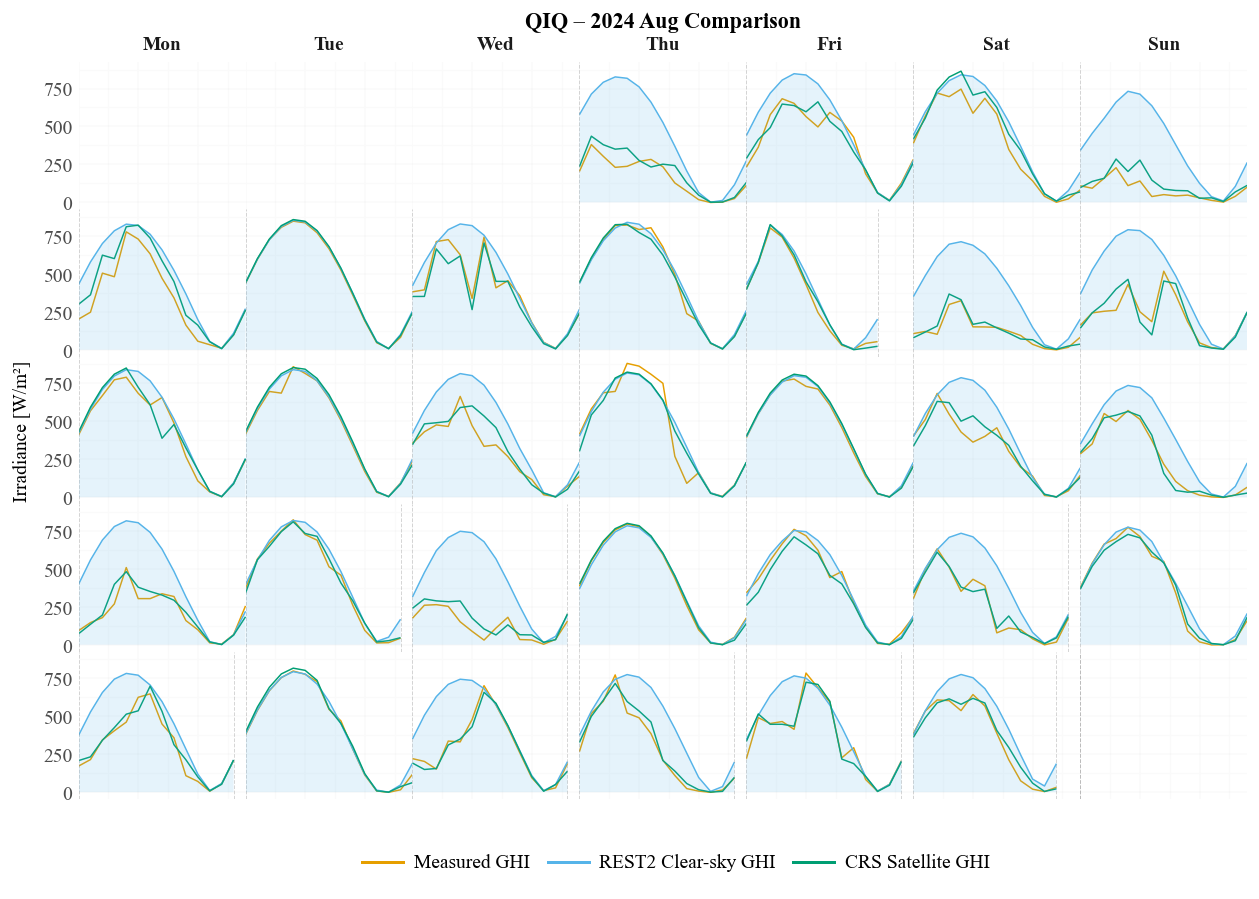

In [6]:
p = bsrn.visualization.calendar.plot_calendar(
    df=df_avg,
    output_file=None, # Display inline instead of saving / 仅在线显示不保存文件
    station_code=station_code,
    meas_col='ghi',
    clear_col='ghi_clear',
    other_cols=['ghi_crs'],
    labels=['Measured GHI', 'REST2 Clear-sky GHI', 'CRS Satellite GHI'],
)

p